# Hackathon-Team: ByteBots

## Challa Srikrishna Reddy (ES22BTECH11006)
## R Kiran Kumar(ES22BTECH11030)

In [1]:
import pandas as pd
import numpy as np

In [2]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", test_data.shape)
train_data.head()

Train Data Shape: (112569, 58)
Test Data Shape: (15921, 57)


,UID,AgriculturalPostalZone,AgricultureZoningCode,CropFieldConfiguration,CropSpeciesVariety,CultivatedAndWildArea,CultivatedAreaSqft1,DistrictId,FarmClassification,FarmEquipmentArea,...,TotalTaxAssessed,TotalValue,TownId,TypeOfIrrigationSystem,UndergroundStorageSqft,ValuationYear,WaterAccessPoints,WaterAccessPointsCalc,WaterReservoirCount,Target
0,12998,291674,0.0,NaN,3.0,NaN,1136.0,1.0,NaN,NaN,...,8636.716,456255.6,118.0,NaN,NaN,2018.0,2.0,2.0,NaN,high
1,20860,164397,28.0,NaN,4.0,NaN,2083.0,1.0,NaN,NaN,...,18464.292,996887.6,24.0,1.0,NaN,2018.0,3.0,3.0,1.0,medium
2,75725,616532,0.0,NaN,2.0,NaN,922.0,1.0,NaN,NaN,...,15594.568,1043780.0,9.0,1.0,NaN,2018.0,1.0,1.0,NaN,medium
3,106521,942111,43.0,NaN,7.0,NaN,NaN,1.0,NaN,NaN,...,8494.618,435734.8,114.0,NaN,NaN,2020.0,3.0,3.0,NaN,low
4,99467,475557,38.0,NaN,3.0,NaN,2225.0,3.0,NaN,0.0,...,13517.284,885400.0,6.0,NaN,NaN,2020.0,4.0,4.0,NaN,medium


### Mapping the categorical Strings to numerical form

In [3]:
target_mapping = {'low': 0, 'medium': 1, 'high': 2}
train_data['Target'] = train_data['Target'].map(target_mapping)

y = train_data['Target']
train_data = train_data.drop(columns=['Target'])
train_data.shape

(112569, 57)

### Finding the Percentage of label in train_data
##### Found helpful to study the patterns of data and its biased-ness

In [4]:
unique, counts = np.unique(y, return_counts=True)
percentages = 100 * counts / len(y)


for label, percentage in zip(unique, percentages):
    print(f"Label {label}: {percentage:.2f}%")


Label 0: 20.00%
Label 1: 60.00%
Label 2: 20.00%


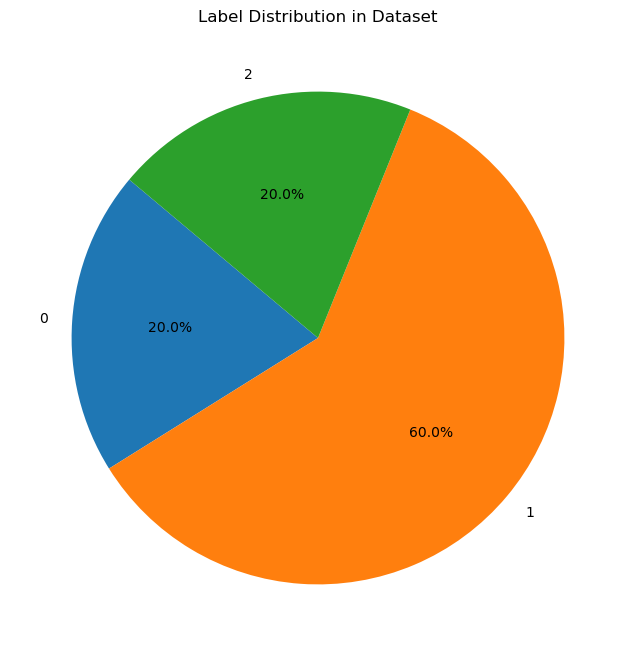

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=unique, autopct='%1.1f%%', startangle=140)
plt.title("Label Distribution in Dataset")
plt.show()


### Observations
-Observed that data is biased towards medium class, hence needed to add class-weights or set threshold to control the outputs

In [6]:
y.head()

0    2
1    1
2    1
3    0
4    1
Name: Target, dtype: int64

### Seperating the UID variables

In [7]:
uid_train = train_data['UID']
uid_test = test_data['UID']
train_data = train_data.drop(columns = ['UID'])
test_data = test_data.drop(columns = ['UID'])

## preprocessing of data: Feature Engineering

### Finding The percentage of NaN values and number of unique values in each column

In [8]:
nan_percentage = train_data.isna().mean() * 100  
unique_counts = train_data.nunique() 

summary_df = pd.DataFrame({
    'NaN Percentage': nan_percentage,
    'Unique Values': unique_counts
})

summary_df


,NaN Percentage,Unique Values
AgriculturalPostalZone,0.000000,105172
AgricultureZoningCode,0.119038,46
CropFieldConfiguration,99.737939,6
CropSpeciesVariety,0.017767,17
CultivatedAndWildArea,99.518518,460
CultivatedAreaSqft1,4.904547,5240
DistrictId,0.017767,3
FarmClassification,99.984898,2
FarmEquipmentArea,66.825680,913
FarmShedAreaSqft,96.978742,658


### PLotting for better understanding of each feature

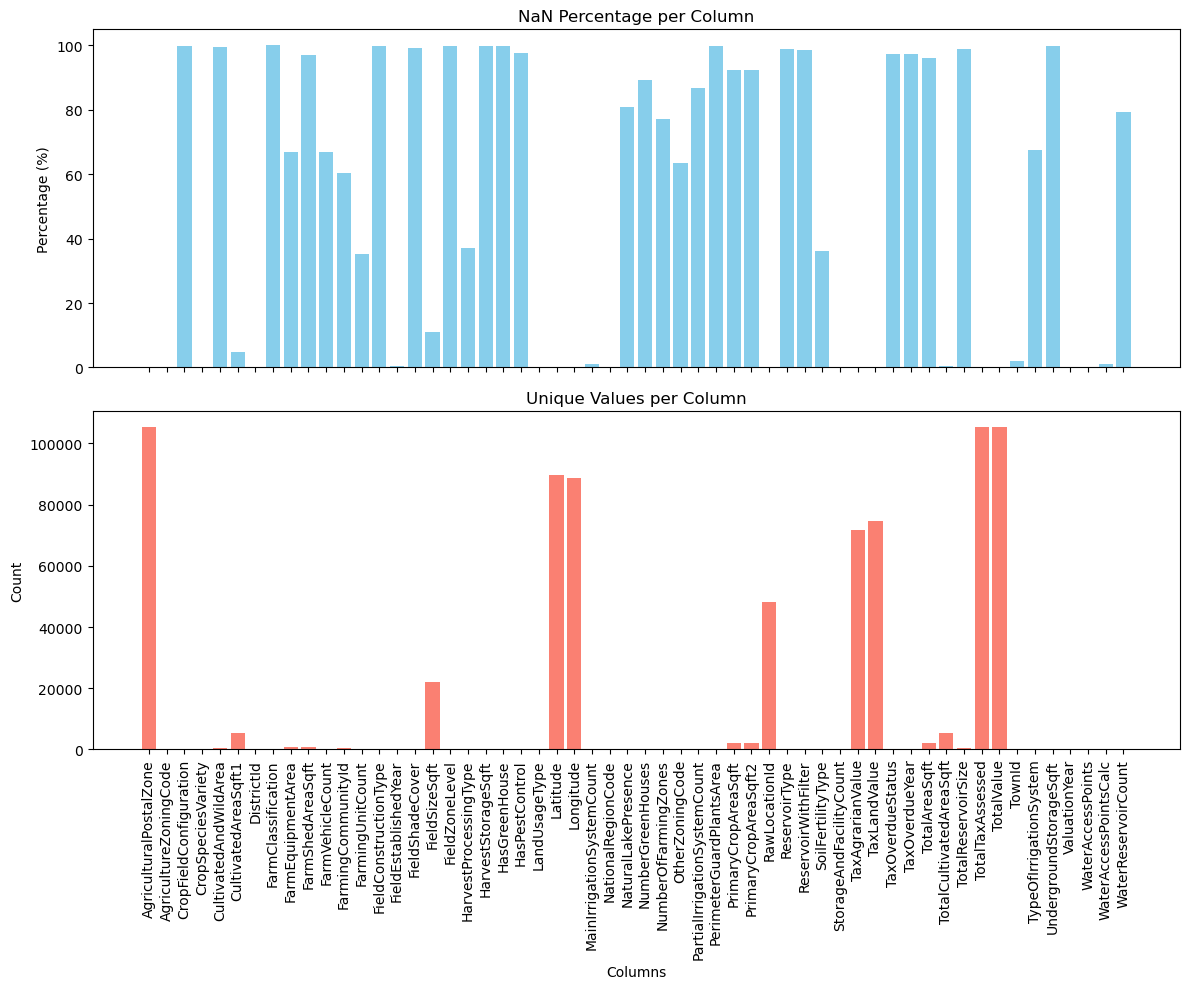

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

nan_percentage = train_data.isna().mean() * 100  
unique_counts = train_data.nunique()  

summary_df = pd.DataFrame({
    'NaN Percentage': nan_percentage,
    'Unique Values': unique_counts
})

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax[0].bar(summary_df.index, summary_df['NaN Percentage'], color='skyblue')
ax[0].set_title('NaN Percentage per Column')
ax[0].set_ylabel('Percentage (%)')
ax[0].tick_params(axis='x', rotation=90)

ax[1].bar(summary_df.index, summary_df['Unique Values'], color='salmon')
ax[1].set_title('Unique Values per Column')
ax[1].set_ylabel('Count')
ax[1].tick_params(axis='x', rotation=90)

plt.xlabel('Columns')
plt.tight_layout()
plt.show()


#### Based on above plot, its found that the following columns has no significance for prediction and few duplicates are included as well. Removed after eyeballing the data

In [10]:
columns_to_remove = [
    'RawLocationId', 'TownId', 'DistrictId', 'FarmingCommunityId', 
    'AgriculturalPostalZone', 'WaterAccessPointsCalc', 
    'PrimaryCropAreaSqft2', 'CultivatedAreaSqft1' 
]
train_data = train_data.drop(columns=columns_to_remove)
test_data = test_data.drop(columns=columns_to_remove)
train_data.shape, test_data.shape


((112569, 48), (15921, 48))

### Based on observations, Data having more than 80% of missing values has no contribution to prediction hence dropping them from the dataframe
### Columns are dropped from both train and test to avoid inconsistency

In [11]:
missing_percent = train_data.isnull().mean() * 100
columns_to_drop = missing_percent[missing_percent > 80].index

train_data = train_data.drop(columns=columns_to_drop)
test_data = test_data.drop(columns=columns_to_drop, errors='ignore')

print("Columns dropped due to >80% NaN values:", columns_to_drop.tolist())
print("Train Data Shape after dropping:", train_data.shape)
print("Test Data Shape after dropping:", test_data.shape)

Columns dropped due to >80% NaN values: ['CropFieldConfiguration', 'CultivatedAndWildArea', 'FarmClassification', 'FarmShedAreaSqft', 'FieldConstructionType', 'FieldShadeCover', 'FieldZoneLevel', 'HarvestStorageSqft', 'HasGreenHouse', 'HasPestControl', 'NaturalLakePresence', 'NumberGreenHouses', 'PartialIrrigationSystemCount', 'PerimeterGuardPlantsArea', 'PrimaryCropAreaSqft', 'ReservoirType', 'ReservoirWithFilter', 'TaxOverdueStatus', 'TaxOverdueYear', 'TotalAreaSqft', 'TotalReservoirSize', 'UndergroundStorageSqft']
Train Data Shape after dropping: (112569, 26)
Test Data Shape after dropping: (15921, 26)


### Finding the central tendency measures for leftover columns for further preprocessing

In [12]:

mean_values = train_data.mean().round(3)
median_values = train_data.median().round(3)
variance_values = train_data.var().round(3)
n_unique_values = train_data.nunique() 
mode_values = train_data.mode().iloc[0].round(3)

summary_stats = pd.DataFrame({
    'Unique Values': n_unique_values,
    'Mode': mode_values,
    'Mean': mean_values,
    'Median': median_values,
    'Variance': variance_values
})

summary_stats = summary_stats.map(lambda x: f"{x:.3f}")
summary_stats


,Unique Values,Mode,Mean,Median,Variance
AgricultureZoningCode,46.000,0.000,16.678,20.000,200.584
CropSpeciesVariety,17.000,3.000,3.047,3.000,1.308
FarmEquipmentArea,913.000,0.000,348.506,436.000,68624.178
FarmVehicleCount,13.000,2.000,1.814,2.000,0.345
FarmingUnitCount,12.000,1.000,1.111,1.000,1.334
FieldEstablishedYear,134.000,1959.000,1972.851,1974.000,560.115
FieldSizeSqft,21969.000,6000.000,29825.834,7204.000,16323536760.208
HarvestProcessingType,12.000,1.000,1.381,1.000,0.467
LandUsageType,13.000,1.000,1.591,1.000,1.652
Latitude,89767.000,24357665.986,24380334.989,24395350.986,70197852503.223


### Based on observations, columns having more than 200 unique values are filled with median of column for NaN values and crest of them use mode beacuse of number of unique values limitations

In [13]:
print("NaN values before in train_data:", train_data.isnull().sum().sum())
print("NaN values before in test_data:", test_data.isnull().sum().sum())

for col in train_data.columns:
    if train_data[col].nunique() > 200:
            mean_value = train_data[col].median()
            train_data[col].fillna(mean_value, inplace=True)
            test_data[col].fillna(mean_value, inplace=True)
    else:
            mode_value = train_data[col].mode()[0]
            train_data[col].fillna(mode_value, inplace=True)
            test_data[col].fillna(mode_value, inplace=True)


print("NaN values remaining in train_data:", train_data.isnull().sum().sum())
print("NaN values remaining in test_data:", test_data.isnull().sum().sum())


NaN values before in train_data: 612359
NaN values before in test_data: 86681
NaN values remaining in train_data: 0
NaN values remaining in test_data: 0


### plotted the longitude and latitude scatter plot, to find if this forms cluster..however found no use for the prediction

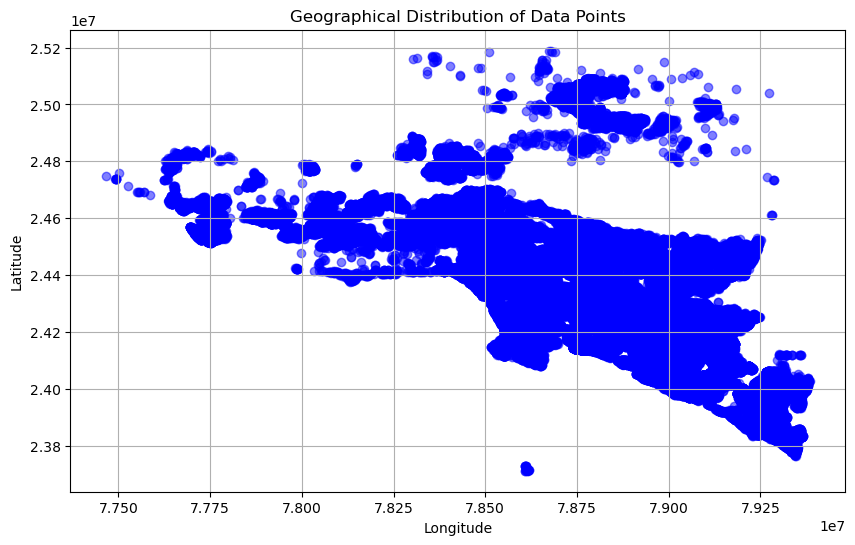

In [14]:
latitude = train_data['Latitude']
longitude = train_data['Longitude']


plt.figure(figsize=(10, 6))
plt.scatter(longitude, latitude, c='blue', alpha=0.5, marker='o')


plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical Distribution of Data Points')
plt.grid(True)
plt.show()


In [15]:
train_data.shape, test_data.shape

((112569, 26), (15921, 26))

## End of preprocessing, model build begins

#### Utilised Regular Random Forest Algorithm

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

rf_model_start = RandomForestClassifier(n_estimators=100, random_state=42)
X = train_data
y = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
rf_model_start.fit(X_train, y_train)

y_pred_start = rf_model_start.predict(X_test)

f1_macro = f1_score(y_test, y_pred_start, average='macro')
print("Macro F1 Score:", f1_macro)

f1_low = f1_score(y_test, y_pred_start, labels=[0], average='macro')  
f1_medium = f1_score(y_test, y_pred_start, labels=[1], average='macro')  
f1_high = f1_score(y_test, y_pred_start, labels=[2], average='macro')  

print(f"F1 Score for low class: {f1_low}")
print(f"F1 Score for medium class: {f1_medium}")
print(f"F1 Score for high class: {f1_high}")



Macro F1 Score: 0.3544504937159094
F1 Score for low class: 0.15690812311964822
F1 Score for medium class: 0.7433727243692111
F1 Score for high class: 0.16307063365886895


### Observation: observed that data is imbalanced(low & high), hence need to set a certain threshold to build model with better f1-score that dosen't overfit the model

#### After checking on various Treshold values, final RF model is built, based on class probabilities for each sample and then uses argmax to align the model towards the class

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
X = train_data
y = y

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def adjust_predictions(y_prob, threshold_low, threshold_high):
    y_pred_adjusted = y_prob.argmax(axis=1)
    for i in range(len(y_pred_adjusted)):
        if y_prob[i, 0] > threshold_low:
            y_pred_adjusted[i] = 0
        elif y_prob[i, 2] > threshold_high:
            y_pred_adjusted[i] = 2
        else:
            y_pred_adjusted[i] = 1
    return y_pred_adjusted

f1_scores = []

threshold_low = 0.31
threshold_high = 0.25

for fold, (train_index, test_index) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    rf_model.fit(X_train, y_train)
    y_prob = rf_model.predict_proba(X_test)
    y_pred_adjusted = adjust_predictions(y_prob, threshold_low, threshold_high)
    
    fold_f1 = f1_score(y_test, y_pred_adjusted, average='macro')
    f1_scores.append(fold_f1)
    
    print(f"F1 Score for Fold {fold}: {fold_f1:.3f}")

average_f1_score = np.mean(f1_scores)
print(f"Average Macro F1 Score across 5 folds: {average_f1_score:.3f}")


F1 Score for Fold 1: 0.418
F1 Score for Fold 2: 0.416
F1 Score for Fold 3: 0.417
F1 Score for Fold 4: 0.421
F1 Score for Fold 5: 0.422
Average Macro F1 Score across 5 folds: 0.419


#### Inorder to check if data is consistent to each fold, used 5-fold cross validation to confirm if the model is balanced to each piece of sample

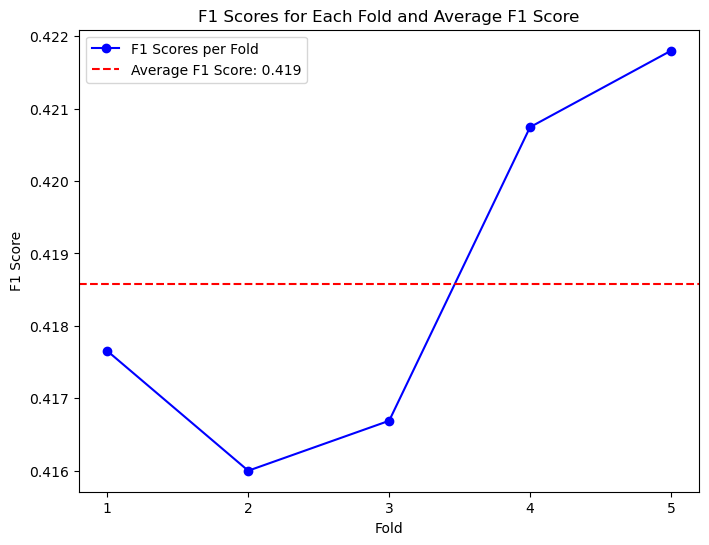

In [18]:

# Plotting F1 scores for each fold
plt.figure(figsize=(8, 6))
plt.plot(range(1, 6), f1_scores, marker='o', linestyle='-', color='b', label='F1 Scores per Fold')
plt.axhline(y=average_f1_score, color='r', linestyle='--', label=f'Average F1 Score: {average_f1_score:.3f}')
plt.title('F1 Scores for Each Fold and Average F1 Score')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.xticks(range(1, 6))
plt.legend()
plt.show()


### PLot describes that dataSet is now balannced and safely aligned to each class instead of being biased.
#### Built the final Random forest model along with optimal Threshold values to test on the model.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
X = train_data  
y = y 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

rf_model.fit(X_train, y_train)

y_prob = rf_model.predict_proba(X_test)

threshold_high = 0.25
y_pred_adjusted = y_prob.argmax(axis=1)  


threshold_low = 0.31 

for i in range(len(y_pred_adjusted)):
    if y_prob[i, 0] > threshold_low:
        y_pred_adjusted[i] = 0  # Low class
    elif y_prob[i, 2] > threshold_high:
        y_pred_adjusted[i] = 2  # High class
    else:
        y_pred_adjusted[i] = 1 


f1_macro = f1_score(y_test, y_pred_adjusted, average='macro')
print("Macro F1 Score:", f1_macro)

f1_low = f1_score(y_test, y_pred_adjusted, labels=[0], average='macro')  
f1_medium = f1_score(y_test, y_pred_adjusted, labels=[1], average='macro')  
f1_high = f1_score(y_test, y_pred_adjusted, labels=[2], average='macro')  

print(f"F1 Score for low class: {f1_low}")
print(f"F1 Score for medium class: {f1_medium}")
print(f"F1 Score for high class: {f1_high}")


Macro F1 Score: 0.4137313834352043
F1 Score for low class: 0.27123745819397993
F1 Score for medium class: 0.6602979755481859
F1 Score for high class: 0.3096587165634471


### now, tested on various other Algorithms-observed that scikit learns's Gradient boosting Algorithm overfits the model and hence used Extreme Gradient Boosting Algorithm which increases f1 score and controls overfitting.

#### PLease use !pip install xgboost to download the Model

F1 Score for Fold 1: 0.430
F1 Score for Fold 2: 0.427
F1 Score for Fold 3: 0.426
F1 Score for Fold 4: 0.428
F1 Score for Fold 5: 0.434
Average Macro F1 Score across 5 folds: 0.429


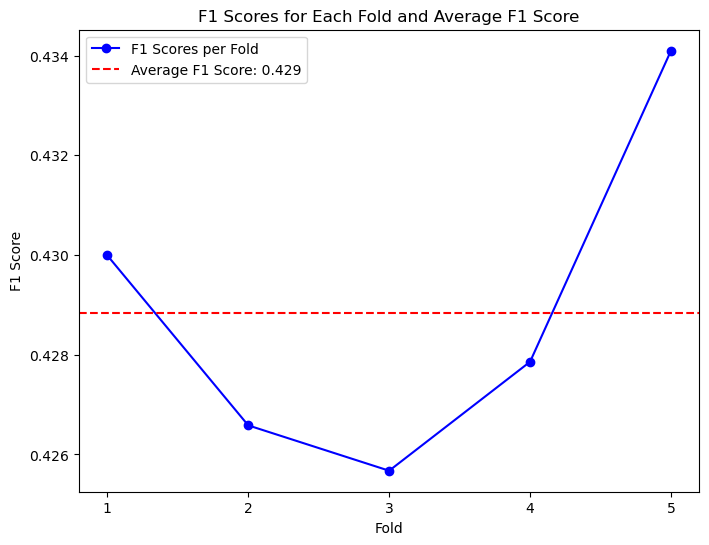

In [20]:

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
X = train_data
y = y

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def adjust_predictions(y_prob, threshold_low, threshold_high):
    y_pred_adjusted = y_prob.argmax(axis=1)
    for i in range(len(y_pred_adjusted)):
        if y_prob[i, 0] > threshold_low:
            y_pred_adjusted[i] = 0
        elif y_prob[i, 2] > threshold_high:
            y_pred_adjusted[i] = 2
        else:
            y_pred_adjusted[i] = 1
    return y_pred_adjusted

f1_scores = []

threshold_low = 0.31
threshold_high = 0.25

for fold, (train_index, test_index) in enumerate(cv.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    xgb_model.fit(X_train, y_train)
    y_prob = xgb_model.predict_proba(X_test)
    y_pred_adjusted = adjust_predictions(y_prob, threshold_low, threshold_high)
    
    fold_f1 = f1_score(y_test, y_pred_adjusted, average='macro')
    f1_scores.append(fold_f1)
    
    print(f"F1 Score for Fold {fold}: {fold_f1:.3f}")

average_f1_score = np.mean(f1_scores)
print(f"Average Macro F1 Score across 5 folds: {average_f1_score:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(range(1, 6), f1_scores, marker='o', linestyle='-', color='b', label='F1 Scores per Fold')
plt.axhline(y=average_f1_score, color='r', linestyle='--', label=f'Average F1 Score: {average_f1_score:.3f}')
plt.title('F1 Scores for Each Fold and Average F1 Score')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.xticks(range(1, 6))
plt.legend()
plt.show()


### Observed that Model is Consistent with each fold after 5 fold CV

## Building the final Model

In [21]:
threshold_low_range = np.arange(0.22, 0.31, 0.01)
threshold_high_diff = np.arange(0.04, 0.09, 0.01)


xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)


y_prob = xgb_model.predict_proba(X_test)
y_pred_base = y_prob.argmax(axis=1)  

best_f1_macro = 0
best_threshold_low = 0
best_threshold_high = 0

for threshold_low in threshold_low_range:
    for diff in threshold_high_diff:
        threshold_high = min(threshold_low + diff, 0.30) 
        
        y_pred_adjusted = y_pred_base.copy()
        
        for i in range(len(y_pred_adjusted)):
            if y_pred_adjusted[i] == 1:
                if y_prob[i, 0] > threshold_high:
                    y_pred_adjusted[i] = 0 
                elif y_prob[i, 2] > threshold_low:
                    y_pred_adjusted[i] = 2
        
        f1_macro = f1_score(y_test, y_pred_adjusted, average='macro')
        
        if f1_macro > best_f1_macro:
            best_f1_macro = f1_macro
            best_threshold_low = threshold_low
            best_threshold_high = threshold_high

print(f"Optimal Threshold Low: {best_threshold_low}, Optimal Threshold High: {best_threshold_high}")
print(f"Best Macro F1 Score with optimal thresholds: {best_f1_macro}")

Optimal Threshold Low: 0.23, Optimal Threshold High: 0.27
Best Macro F1 Score with optimal thresholds: 0.44354288249567037


### It checks for best Threshold values that avoids overfitting the model

In [23]:
y_prob = xgb_model.predict_proba(X_test) 

threshold_high = best_threshold_low
y_pred_adjusted = y_prob.argmax(axis=1)

threshold_low = best_threshold_high

for i in range(len(y_pred_adjusted)):
    if y_pred_adjusted[i] == 1:
        if y_prob[i, 0] > threshold_low:
            y_pred_adjusted[i] = 0 
        elif y_prob[i, 2] > threshold_high:
            y_pred_adjusted[i] = 2


f1_macro = f1_score(y_test, y_pred_adjusted, average='macro')
print("Macro F1 Score:", f1_macro)


f1_low = f1_score(y_test, y_pred_adjusted, labels=[0], average='macro')  # For low class
f1_medium = f1_score(y_test, y_pred_adjusted, labels=[1], average='macro')  # For medium class
f1_high = f1_score(y_test, y_pred_adjusted, labels=[2], average='macro')  # For high class

print(f"F1 Score for low class: {f1_low}")
print(f"F1 Score for medium class: {f1_medium}")
print(f"F1 Score for high class: {f1_high}")



Macro F1 Score: 0.44354288249567037
F1 Score for low class: 0.3267472056000903
F1 Score for medium class: 0.6760647646113002
F1 Score for high class: 0.32781667727562064


## Testing on Test data and storing the file into submission.csv

In [25]:
y_prob = xgb_model.predict_proba(test_data)
y_pred = y_prob.argmax(axis=1)
for i in range(len(y_pred)):
    if y_pred[i] == 1:
        if y_prob[i, 0] > threshold_low:
            y_pred[i] = 0
        elif y_prob[i, 2] > threshold_high:
            y_pred[i] = 2

test_predictions = y_pred

In [ ]:
# Reverse the target mapping to get labels (low, medium, high)
reverse_target_mapping = {0: 'low', 1: 'medium', 2: 'high'}
test_predictions_labels = [reverse_target_mapping[pred] for pred in test_predictions]

submission = pd.DataFrame({
    'UID': uid_test,
    'Target': test_predictions_labels
})

submission.to_csv('submission.csv', index=False)

In [ ]:
import argparse
def make_predictions(test_fname, predictions_fname):
    test = pd.read_csv(test_fname)
    fill_na_values(test, features, vals)
    test_X = test[features].to_numpy()
    preds = model.predict(test_X)
    test_uid = test[["UID"]].copy()
    test_uid["Target"] = preds.reshape(-1)
    test_uid.to_csv(predictions_fname, index=False)

if __name__=="__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--train-file", type=str, help=’file path of train.csv’)
    parser.add_argument("--test-file", type=str, help=’file path of test.csv’)
    parser.add_argument("--predictions-file", type=str, help=’save path of predictions’)
    args = parser.parse_args()
    make_predictions(args.test_file, args.predictions_file)